V3.1 -  Moving Aircraft And Static Radar

In [2]:
# Initialize libraries and functions PC
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import cv2
import numpy as np
import math
import random
import time as timess
from prettytable import PrettyTable
from IPython.display import clear_output, Markdown, display
from abc import ABC, abstractmethod
import csv

def db_to_normal(x):
    return 10**(x/10)

def normal_to_db(x):
    return 10*math.log10(x)

def pdw_tabular_print(pdw,time):
    if(len(pdw)>1):
        display(Markdown('{}<strong>{}</strong>{}'.format('PDW\'s of the recieved pulses in ',str(time//10)+' nano seconds',' are as follows')))
        t = PrettyTable(list(pdw[0].keys()))
        for i in pdw[:]:
            t.add_row(list(i.values()))
        print(t)

# base_noise_min=db_to_normal(-1000)
# base_noise_max=db_to_normal(-75)
base_noise_min=db_to_normal(-1000*1000)
base_noise_max=db_to_normal(-75*1000)
ci=0#len(time)//4
cf=10000
cf=10000
fig_x , fig_y = 25 , 2
clrs= 'rgbcmyk'
rand_skew=0
mult = 2
print(90//mult,360-90//mult,360-((360-90//mult)-(90//mult)))

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


45 315 90


In [3]:
# # Initiallize tables
# rf = open("../Radar_G_table_3d.txt", "w")
# # f = open("../RWR_G_table_omni.txt", "w")
# for j in range(5,185,5):#frequency
#     for k in range(360):
#         # print(j,k)
#         # f.write(str(j/10)+' '+str(k))
#         # f.write(' | ')
#         rf.write(str(j/10)+' '+str(k))
#         rf.write(' | ')
#         for i in range(360):
#             if(((i>=0 and i<=90//mult) or (i>=360-(90//mult) and i<360)) and ((k>=0 and k<=90//mult) or (k>=360-(90//mult) and k<360))):
#                 # f.write(str(math.cos(math.radians(0))*math.cos(math.radians(0)))+' ')
#                 rf.write(str(math.cos(math.radians(mult*i))*math.cos(math.radians(mult*k)))+' ')
#             else:
#                 # f.write(str(0)+' ')
#                 rf.write(str(0)+' ')
#         # f.write('\n')
#         rf.write('\n')
# # f.close()
# rf.close()

In [4]:
# f = open("../angle_table.txt", "w")
# for th in range(-45,45):
#     a1=round(normal_to_db(math.cos(math.radians(45+th))),4)
#     a2=round(normal_to_db(math.cos(math.radians(45-th))),4)
#     f.write(str(round(a2-a1,5))+',')
# th=45
# a1=round(normal_to_db(math.cos(math.radians(45+th))),4)
# a2=round(normal_to_db(math.cos(math.radians(45-th))),4)
# f.write(str(round(a2-a1,5)))
# f.close()

In [5]:
RWR_G_table={}
f = open("RWR_G_table_omni.txt", "r")
Lines = f.readlines()
for line in Lines:
    tmp=list(line.split())
    tmp_freq=float(tmp[0])
    tmp_azi=int(tmp[1])
    tmp=tmp[3:]
    # print(tmp_freq,tmp_azi,tmp)
    if(tmp_freq not in RWR_G_table):
        RWR_G_table[tmp_freq]=[[]]
    if(len(RWR_G_table[tmp_freq])-1<tmp_azi):
        RWR_G_table[tmp_freq].append([])
    tmp_list=[]
    for radar in tmp:
        tmp_list.append(float(radar))
    RWR_G_table[tmp_freq][tmp_azi]=tmp_list
f.close()

Radar_G_table={}
f = open("Radar_G_table_3d.txt", "r")
Lines = f.readlines()
for line in Lines:
    tmp=list(line.split())
    tmp_freq=float(tmp[0])
    tmp_azi=int(tmp[1])
    tmp=tmp[3:]
    # print(tmp_freq,tmp_azi,tmp)
    if(tmp_freq not in Radar_G_table):
        Radar_G_table[tmp_freq]=[[]]
    if(len(Radar_G_table[tmp_freq])-1<tmp_azi):
        Radar_G_table[tmp_freq].append([])
    tmp_list=[]
    for radar in tmp:
        tmp_list.append(float(radar))
    Radar_G_table[tmp_freq][tmp_azi]=tmp_list
f.close()

f = open("angle_table.txt", "r")
angle_table=tuple(map(float,f.read().split(',')))
f.close()

In [6]:
class battle_system(ABC):
    def __init__(self):
        pass

    @abstractmethod
    def get(self):
        pass
        
    @abstractmethod
    def set(self):
        pass
        
    @abstractmethod
    def ontick(self):
        pass
    
    def __del__(self):
        pass

In [7]:
class platform(battle_system):
    def __init__(self, pos=(0,0,0),speed=0,onboard_systems=[]):
        super().__init__()
        if(len(pos)==2):
            self.position = list(pos)+[0]
        else:
            self.position = pos
        self.speed = speed
        self.onboard_systems = onboard_systems
    
    def __del__(self):
        super().__del__()

In [8]:
class aircraft(platform):
    def __init__(self, id,heading=0,speed=10,aircraftWaypoints=[],onboard_systems=[]):
        super().__init__(aircraftWaypoints[0] ,speed,onboard_systems)
        self.id = id                                       # Id of the Aircraft
        self.heading = heading                             # heading of the Aircraft in degrees
        for i in range(len(aircraftWaypoints)):
            if len(aircraftWaypoints[i])==2:
                aircraftWaypoints[i]=list(aircraftWaypoints[i])+[0]
        self.aircraftWaypoints=aircraftWaypoints
        self.next_waypoint=1
        
    def move_aircraft(self):
        if(len(self.aircraftWaypoints)>1):
            time_diff=1
            cur_pos=list(self.position)
            next_waypoint=self.next_waypoint
            d=math.dist(self.aircraftWaypoints[next_waypoint],cur_pos)
            idx=0
            while(d < (self.speed*time_diff)):
                idx += 1
                next_waypoint += 1
                if (next_waypoint== len(self.aircraftWaypoints)):
                    next_waypoint = 0
                if(idx>len(self.aircraftWaypoints)*2):
                    raise Exception("Aircraft speed is too much")
                d=math.dist(self.aircraftWaypoints[next_waypoint],cur_pos)
            heading=math.degrees(math.atan2(self.aircraftWaypoints[next_waypoint][1] - cur_pos[1],self.aircraftWaypoints[next_waypoint][0] - cur_pos[0]))
            while(heading>=360):
                heading-=360
            while(heading<0):
                heading+=360
            self.heading=heading
            cur_pos[0] += ((self.speed * time_diff) * (self.aircraftWaypoints[next_waypoint][0] - cur_pos[0]) / d)
            cur_pos[1] += ((self.speed * time_diff) * (self.aircraftWaypoints[next_waypoint][1] - cur_pos[1]) / d)
            self.position=cur_pos
            self.next_waypoint=next_waypoint

    def get(self):
        return self.position
        
    def set(self):
        pass
        
    def ontick(self):
        self.move_aircraft()
    
    def __del__(self):
        super().__del__()

In [9]:
class sensor(battle_system):
    def __init__(self,host_platform):
        super().__init__()
        self.host_platform = host_platform
    
    def __del__(self):
        super().__del__()

In [10]:
class radar(sensor):
    def __init__(self, id,pri=500,pwd=10,azimuth=0,radarWaypoints=[],signature_type='fixed',mode="circular",host_platform=[]):
        super().__init__(host_platform)
        for i in range(len(radarWaypoints)):
            if len(radarWaypoints[i])==2:
                radarWaypoints[i]=list(radarWaypoints[i])+[0]
        self.id = id                                       # Id of the radar
        self.pri = pri                                     # Pulse Repetition Interval 1 nano seconds
        self.pwd = pwd                                     # Pulse Width in 1 nano seconds
        self.Pt = (10**10)*1                                # Peak transmitted power
        self.freq = 10.0                                   # frequency range 0.5 to 18 units gigahertz
        self.azimuth = azimuth                             # azimuth of the radar in degrees
        self.elevation = 0                             # elevation of the radar in degrees
        self.signature_type=signature_type[0]
        self.sig_data=signature_type
        self.impedance = 50
        self.position = radarWaypoints[0]
        self.speed=.1
        self.rot_speed = 5
        self.radarWaypoints=radarWaypoints
        self.next_waypoint=1
        self.mode=mode
        self.airc_pos=None
        self.clockWise=True
        self.raster_clockWise=True
        self.spiral_increse=True
        

    def move_radar(self):


        conical_theta_speed=2
        conical_theta=0
        conical_rad=5
        conical_dis=10
        raster_elevation=60
        raster_speed=5
        palmer_raster_speed=20
        conical_rad_spiral=conical_rad
        palmer_azimuth=-30
        palmer_azimuth_speed=10

        if(len(self.radarWaypoints)>1):
            time_diff=1
            cur_pos=list(self.position)
            next_waypoint=self.next_waypoint
            d=math.dist(self.radarWaypoints[next_waypoint],cur_pos)
            idx=0
            while(d < (self.speed*time_diff)):
                idx += 1
                next_waypoint += 1
                if (next_waypoint== len(self.radarWaypoints)):
                    next_waypoint = 0
                if(idx>len(self.radarWaypoints)*2):
                    raise Exception("Radar "+self.id+"'s speed is too much")
                d=math.dist(self.radarWaypoints[next_waypoint],cur_pos)
            # heading=math.degrees(math.atan2(self.radarWaypoints[next_waypoint][1] - cur_pos[1],self.radarWaypoints[next_waypoint][0] - cur_pos[0]))
            # while(heading>=360):
            #     heading-=360
            # while(heading<0):
            #     heading+=360
            # self.heading=heading
            cur_pos[0] += ((self.speed * time_diff) * (self.radarWaypoints[next_waypoint][0] - cur_pos[0]) / d)
            cur_pos[1] += ((self.speed * time_diff) * (self.radarWaypoints[next_waypoint][1] - cur_pos[1]) / d)
            self.position=cur_pos
            self.next_waypoint=next_waypoint
        if(len(self.airc_pos)>0):
            airc_pos=self.airc_pos
            radar_pos=self.position
            
            heading_angle=int(math.degrees(math.atan2(airc_pos[1]-radar_pos[1],self.airc_pos[0]-radar_pos[0])))#+180
            heading_noise_range=0
            if (self.mode=="circular"):
                self.azimuth=((self.azimuth+self.rot_speed)%360) if self.clockWise else((self.azimuth-self.rot_speed)%360)
                self.elevation=0
            elif (self.mode=="sector"):
                min_sector=30
                max_sector=250
                if(self.azimuth<min_sector+self.rot_speed and self.azimuth>min_sector-self.rot_speed):
                    self.clockWise=True
                elif(self.azimuth<max_sector+self.rot_speed and self.azimuth>max_sector-self.rot_speed):
                    self.clockWise=False
                self.azimuth = ((self.azimuth+self.rot_speed)%360) if self.clockWise else((self.azimuth-self.rot_speed)%360)
                self.elevation=0
            elif (self.mode=="helical"):
                self.azimuth = ((self.azimuth+self.rot_speed)%360) if self.clockWise else((self.azimuth-self.rot_speed)%360)
                self.elevation = (self.elevation+0.07)%360
            elif (self.mode=="raster"):
                min_sector=30
                max_sector=250
                min_raster_sector=40
                max_raster_sector=-40
                if(self.azimuth<min_sector+self.rot_speed and self.azimuth>min_sector-self.rot_speed):
                    self.clockWise=True
                    if self.raster_clockWise:
                        raster_elevation-=raster_speed
                    else:
                        raster_elevation+=raster_speed
                elif(self.azimuth<max_sector+self.rot_speed and self.azimuth>max_sector-self.rot_speed):
                    self.clockWise=False
                    if self.raster_clockWise:
                        raster_elevation-=raster_speed
                    else:
                        raster_elevation+=raster_speed
                if(self.elevation<min_raster_sector+raster_speed and self.elevation>min_raster_sector-raster_speed):
                    self.raster_clockWise=True
                elif(self.elevation<max_raster_sector+raster_speed and self.elevation>max_raster_sector-raster_speed):
                    self.raster_clockWise=False
                self.azimuth = ((self.azimuth+self.rot_speed)%360) if self.clockWise else((self.azimuth-self.rot_speed)%360)
                self.elevation=raster_elevation
            elif (self.mode=="conical"):
                conical_theta+=conical_theta_speed
                self.azimuth = 180+(math.asin(conical_rad*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi)
                self.elevation = math.asin(conical_rad*math.sin(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi
            elif (self.mode=="spiral"):
                conical_theta+=conical_theta_speed
                if(self.spiral_increse):
                    conical_rad_spiral+=.005
                else:
                    conical_rad_spiral-=.005
                if(abs(conical_rad_spiral)>conical_rad):
                    self.spiral_increse=not self.spiral_increse
                self.azimuth = 180+(math.asin(abs(conical_rad_spiral)*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad_spiral**2+conical_dis**2))*180/math.pi)
                self.elevation = math.asin(abs(conical_rad_spiral)*math.sin(conical_theta*math.pi/180)/math.sqrt(conical_rad_spiral**2+conical_dis**2))*180/math.pi
            elif (self.mode=="palmer"):
                min_sector=30
                max_sector=-40
                conical_theta+=conical_theta_speed
                print(conical_theta,palmer_azimuth)
                if(conical_theta>360):
                    if(palmer_azimuth<min_sector+palmer_azimuth_speed//2 and palmer_azimuth>min_sector-palmer_azimuth_speed//2):
                        self.clockWise=True
                    elif(palmer_azimuth<max_sector+palmer_azimuth_speed//2 and palmer_azimuth>max_sector-palmer_azimuth_speed//2):
                        self.clockWise=False
                    conical_theta-=360
                    if self.clockWise:
                        palmer_azimuth-=palmer_azimuth_speed
                    else:
                        palmer_azimuth+=palmer_azimuth_speed
                self.azimuth = 180+palmer_azimuth+(math.asin(conical_rad*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi)
                self.elevation = math.asin(conical_rad*math.sin(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi
            elif (self.mode=="palmerRaster"):
                print(palmer_azimuth,raster_elevation)
                min_sector=30
                max_sector=-40
                min_raster_sector=40
                max_raster_sector=-40
                conical_theta+=conical_theta_speed
                print(conical_theta,palmer_azimuth)
                if(conical_theta>360):
                    if(palmer_azimuth<min_sector+palmer_azimuth_speed//2 and palmer_azimuth>min_sector-palmer_azimuth_speed//2):
                        self.clockWise=True
                        if self.raster_clockWise:
                            raster_elevation-=palmer_raster_speed
                        else:
                            raster_elevation+=palmer_raster_speed
                    elif(palmer_azimuth<max_sector+palmer_azimuth_speed//2 and palmer_azimuth>max_sector-palmer_azimuth_speed//2):
                        self.clockWise=False
                        if self.raster_clockWise:
                            raster_elevation-=palmer_raster_speed
                        else:
                            raster_elevation+=palmer_raster_speed
                    conical_theta-=360
                    if self.clockWise:
                        palmer_azimuth-=palmer_azimuth_speed
                    else:
                        palmer_azimuth+=palmer_azimuth_speed
                    
                    if(self.elevation<min_raster_sector+palmer_raster_speed and self.elevation>min_raster_sector-palmer_raster_speed):
                        self.raster_clockWise=True
                    elif(self.elevation<max_raster_sector+palmer_raster_speed and self.elevation>max_raster_sector-palmer_raster_speed):
                        self.raster_clockWise=False
                self.azimuth = 180+palmer_azimuth+(math.asin(conical_rad*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi)
                self.elevation = math.asin(conical_rad*math.sin(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi+raster_elevation
            else:
                self.azimuth = random.randint(heading_angle-heading_noise_range,heading_angle+heading_noise_range)
                self.elevation = 0

    def get(self):
        return self.position
        
    def set(self,aircraft_pos):
        self.airc_pos=aircraft_pos
        
    def ontick(self):
        self.move_radar()
    
    def __del__(self):
        super().__del__()

In [11]:
class rwr(sensor):
    def __init__(self, number_of_antennas,host_platform):
        super().__init__(host_platform)
        self.number_of_antennas=number_of_antennas
        self.threats=[]
        self.pdws=[]
        self.emitter_records=[]
        self.recieved_power=[]
        self.tempAngleDiff = 0
    

    def get(self):
        return self.recieved_power

    def set(self,recieved_power):
        self.recieved_power=recieved_power

    def ontick(self):
        # run ER generator and ETM
        pass
        
    def __del__(self):
        super().__del__()

In [12]:
class dtse:
    def __init__(self, radars, aircraft_0):
        self.radars=radars
        self.aircraft=aircraft_0
    
    def get_power_recieved_by_rwr(self,radars,aircraft):
        p=[]
        for i in radars:
            p.append(self.Recieved_power(i))
        return p

    def Recieved_power(self,radar):
        global RWR_G_table,Radar_G_table,angle_table,base_noise_min,base_noise_max,time,receivers_n,rwr_antenna_n,rand_skew,slope,antenna_length
        R = math.dist(radar.position,self.aircraft.position)*100      # Distance between the radar and the aircraft
        if(R<1):
            R=1
        Pt = radar.Pt                                 # Peak transmitted power
        freq = radar.freq                             # carrier frequency
        # Lambda=3*(10**8)/radar.freq
        Lambda=2
        powers = []
        angl_cond=[315,225,135,45]                  # we are producing the pulse train for the 4 recievers
        # for j in range(receivers_n):                          # front left, rear left, rear right and front right respectively
        #     angl_cond.append((360/receivers_n)*(1+2*j)/2)     # based on the above information
        xy_dist = math.dist(radar.position,self.aircraft.position)
        angle_el=radar.elevation-math.degrees(math.atan2(radar.position[2]-self.aircraft.position[2],xy_dist))
        for j in range(receivers_n):
            temp_x = (self.aircraft.position[0]+(antenna_length*math.cos(math.radians(self.aircraft.heading+(360/receivers_n)*(1+2*j)/2))))
            temp_y = (self.aircraft.position[1]+(antenna_length*math.sin(math.radians(self.aircraft.heading+(360/receivers_n)*(1+2*j)/2))))

            # print(temp_x,temp_y,aircraft.position)
            angle=math.degrees(math.atan2(radar.position[1]-temp_y,
                                            radar.position[0]-temp_x))+(-self.aircraft.heading+angl_cond[j])
            angle_tr=math.degrees(math.atan2(radar.position[1]-temp_y,
                                            radar.position[0]-temp_x))
            while(angle>=360):
                angle-=360                                     # Angle between the aircraft's front direction and radar
            while(angle<0):
                angle+=360
            angle_rad = radar.azimuth

            angle_rd=int((angle_rad-180)-angle_tr)
            while(angle_rd>=360):
                angle_rd-=360                                     # Angle between the radar's boresight and aircraft
            while(angle_rd<0):
                angle_rd+=360
            angle_el=int(angle_el)
            while(angle_el>=360):
                angle_el-=360                                     # Angle between the radar's boresight and aircraft
            while(angle_el<0):
                angle_el+=360
            # print(angle,(angle_rad-180),angle_rd,angle_tr)
            # angle_el=90
            # angle_rd=0
            # print(Radar_G_table[freq][angle_el][angle_rd],angle_el,angle_rd)
            P=(Pt*Radar_G_table[freq][angle_el][angle_rd]*(Lambda**2))/((4*math.pi*R)**2)
            tmp_v=abs(P if angle < 90 or angle>270 else 0)
            if(tmp_v>base_noise_max):
                if(normal_to_db(tmp_v*1000)>-85):
                    powers.append(normal_to_db(tmp_v*1000))
                else:
                    powers.append(-85)
            else:
                powers.append(-85)
        return powers
    
    def driver_run(self, iterations=500):
        global A__t_table,A1_t_table,A2_t_table,A3_t_table,A4_t_table,Ax_t_table,Ay_t_table,Aa_t_table,Rx_t_table,Ry_t_table,Ra_t_table,visualize
        play_back_speed=1
        play_flag=0
        resize=1.5
        tmp_s_r=20
        tmp_s_a=20

        idx=0


        if(visualize):
            img = np.zeros((1400,1400,3), np.uint8)
            cv2.namedWindow("Visualisation", cv2.WINDOW_NORMAL)
            cv2.resizeWindow("Visualisation", int(img.shape[1]/resize), int(img.shape[0]/resize))

        for idx in range(iterations):
            if(visualize):
                print('tick number - ',str(idx+1))

            # --------- Get -------------
            t_pos=self.aircraft.get()
            airc_pos=(int(t_pos[0]),int(t_pos[1]))
            Ax_t_table.append(airc_pos[0])
            Ay_t_table.append(airc_pos[1])
            Aa_t_table.append(self.aircraft.heading)

            radar_positions = []
            tmp_i=0
            for radar in self.radars: 
                t_pos=radar.get()
                radar_positions.append((int(t_pos[0]),int(t_pos[1])))
                radar_pos=radar_positions[tmp_i]
                if(tmp_i==0):
                    Rx_t_table.append(radar_pos[0])
                    Ry_t_table.append(radar_pos[1])
                    Ra_t_table.append(radar.azimuth)
                tmp_i+=1

            for rwr in self.aircraft.onboard_systems:
                t_temp=rwr.get()
                if(len(t_temp)>0):
                    t_temp = t_temp[0]
                    # print(len(FallState))
                    A__t_table.append((t_temp[0] if t_temp[0] > -85 else 0)+(t_temp[1] if t_temp[1] > -85 else 0)+(t_temp[2] if t_temp[2] > -85 else 0)+(t_temp[3] if t_temp[3] > -85 else 0))
                    A1_t_table.append(t_temp[0])
                    A2_t_table.append(t_temp[1])
                    A3_t_table.append(t_temp[2])
                    A4_t_table.append(t_temp[3])
            # --------- Get -------------


            # --------- fuse -------------
            recieved_power = self.get_power_recieved_by_rwr(self.radars,self.aircraft)
            # --------- fuse -------------

            # --------- Set -------------
            self.aircraft.set()
            for radar in self.radars: 
                radar.set(airc_pos)
            for rwr in self.aircraft.onboard_systems:
                rwr.set(recieved_power)
            # --------- Set -------------

            # --------- On Tick -------------
            self.aircraft.ontick()
            for radar in self.radars: 
                radar.ontick()
            for rwr in self.aircraft.onboard_systems:
                rwr.ontick()
            # --------- On Tick -------------

            if(visualize):
                # --------- Visualisation -------------
                img=np.zeros(img.shape,np.uint8)
                for j in range(receivers_n):
                    cv2.line(img,airc_pos,(int(airc_pos[0]+(antenna_length*math.cos(math.radians(self.aircraft.heading+(360/receivers_n)*(1+2*j)/2)))),int(airc_pos[1]+(antenna_length*math.sin(math.radians(self.aircraft.heading+(360/receivers_n)*(1+2*j)/2))))),(0,0,255),2)
                cv2.circle(img,airc_pos,5,(0,255,0),-1)
                airc_head=(int(airc_pos[0]+(antenna_length*1.5*math.cos(math.radians(self.aircraft.heading))))
                        ,int(airc_pos[1]+(antenna_length*math.sin(math.radians(self.aircraft.heading)))))
                cv2.line(img,airc_pos,airc_head,(0,255,0),4)
                #Aircraft waypoints
                # for j in range(len(aircraft_0.aircraftWaypoints)-1):
                #     cv2.line(img,aircraft_0.aircraftWaypoints[j],aircraft_0.aircraftWaypoints[j+1],(255,255,0),2)
                # cv2.line(img,aircraft_0.aircraftWaypoints[-1],aircraft_0.aircraftWaypoints[0],(255,255,0),2)
                for j in range(len(self.radars)):
                    # adding the radars to the image
                    radar_pos=(int(self.radars[j].position[0]),int(self.radars[j].position[1]))
                    cv2.circle(img,radar_pos,7,(255,155,0),-1)
                    cv2.putText(img,str(self.radars[j].id),(radar_pos[0]+20,radar_pos[1]),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),1,cv2.LINE_AA)
                    cv2.line(img,radar_pos,(int(radar_pos[0]+(tmp_s_r*math.cos(math.radians(self.radars[j].azimuth)))),int(radar_pos[1]+(tmp_s_r*math.sin(math.radians(self.radars[j].azimuth))))),(0,0,255),2)
                image=cv2.putText(img,'tick number - '+str(idx),(img.shape[1]*6//10,img.shape[0]*1//10),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2,cv2.LINE_AA)
                cv2.imshow('Visualisation',img)
                idx+=1
                # break
                if(play_flag):
                    # if(idx<15 or (idx>92 and idx<98) or (idx>99 and idx<107)):
                    if((idx>4 and idx<10)):
                        quit_k=cv2.waitKey(play_back_speed) & 0xFF
                        # quit_k=cv2.waitKey(0)&0xFF
                    else:
                        quit_k=cv2.waitKey(play_back_speed) & 0xFF
                else:
                    quit_k = cv2.waitKey(0) & 0xFF
                clear_output(wait=True)
                if quit_k == ord('q'):
                    break
                if quit_k == ord('p'):
                    play_flag=False
                if quit_k == ord('l'):
                    play_flag=True
        if(visualize):
            # cv2.imwrite('Visualisation.jpg',img)
            cv2.destroyAllWindows()
            # --------- Visualisation ------------- 
    
    def __del__(self):
        pass

In [13]:
# Initialization of aircraft, RWR and radars
rwr_antenna_n = 4              # Number of recievers on the aircraft(4 or 6)
radars_n = 3                   # Number of radars
receivers_n = 4 # Effective number of antenna

antenna_length = 10

# Aircraft object is created
#straight line
# aircraft_waypoints = [(1100, 1400), (1100, 00)]
aircraft_waypoints = [(1100, 700)]
#Circle
# aircraft_waypoints = [(100, 1400), (100, 1377), (100, 1354), (101, 1331), (103, 1309), (104, 1286), (107, 1264), (109, 1241), (112, 1219), (116, 1196), (119, 1174), (123, 1151), (128, 1129), (133, 1107), (138, 1085), (144, 1063), (150, 1041), (156, 1019), (163, 998), (170, 976), (178, 955), (186, 934), (194, 913), (203, 892), (212, 871), (221, 850), (231, 830), (241, 809), (252, 789), (262, 769), (274, 750), (285, 730), (297, 711), (309, 691), (322, 673), (335, 654), (348, 635), (361, 617), (375, 599), (389, 581), (404, 564), (418, 547), (433, 530), (449, 513), (464, 496), (480, 480), (496, 464), (513, 449), (530, 433), (547, 418), (564, 404), (581, 389), (599, 375), (617, 361), (635, 348), (654, 335), (673, 322), (691, 309), (711, 297), (730, 285), (749, 274), (769, 262), (789, 252), (809, 241), (830, 231), (850, 221), (871, 212), (892, 203), (913, 194), (934, 186), (955, 178), (976, 170), (998, 163), (1019, 156), (1041, 150), (1063, 144), (1085, 138), (1107, 133), (1129, 128), (1151, 123), (1174, 119), (1196, 116), (1219, 112), (1241, 109), (1264, 107), (1286, 104), (1309, 103), (1331, 101), (1354, 100), (1377, 100)]

#complex
# aircraft_waypoints = [(336, 630), (171, 629), (167, 630), (157, 629), (151, 628), (148, 626), (144, 623), (42, 525), (38, 522), (32, 518), (29, 514), (27, 509), (27, 504), (28, 500), (30, 495), (33, 493), (45, 485), (70, 468), (265, 288), (273, 282), (275, 274), (275, 269), (273, 156), (276, 150), (281, 146), (285, 145), (289, 145), (296, 144), (615, 145), (619, 146), (626, 149), (630, 155), (633, 160), (632, 165), (633, 171), (634, 179), (633, 184), (633, 189), (633, 195), (636, 295), (636, 298), (636, 305), (636, 312), (638, 320), (640, 327), (643, 349), (648, 402), (649, 415), (649, 424), (652, 436), (652, 447), (654, 455), (656, 461), (656, 466), (655, 471), (656, 479), (655, 487), (656, 501), (654, 557), (656, 565), (652, 575), (648, 585), (638, 593), (623, 605), (616, 609), (608, 612), (595, 614), (589, 615), (578, 615), (563, 613), (553, 610), (545, 608), (533, 601), (522, 593), (515, 585), (505, 570), (500, 559), (497, 545), (497, 534), (499, 524), (503, 515), (511, 505), (520, 497), (534, 492), (546, 484), (556, 478), (574, 474), (584, 472), (597, 470), (611, 468), (627, 467), (639, 465), (655, 466), (659, 466), (683, 466), (692, 466), (723, 462), (729, 460), (740, 454), (751, 444), (757, 438), (1099, 109), (1105, 104), (1114, 99), (1121, 96), (1132, 93), (1147, 93), (1166, 93), (1177, 96), (1183, 100), (1188, 107), (1189, 112), (1191, 124), (1194, 140), (1224, 505), (1225, 514), (1225, 522), (1225, 526), (1225, 532), (1225, 547), (1226, 559), (1225, 572), (1231, 615), (1229, 626), (1226, 637), (1217, 649), (1205, 655), (1186, 660), (1165, 662), (1152, 664)]

aircraft_0 = aircraft(id=0,
                      heading=random.uniform(0,360),
                      speed=0.5,
                      aircraftWaypoints=aircraft_waypoints[:])

# RWR object is created

rwr_0 = rwr(number_of_antennas=receivers_n,host_platform=aircraft_0)
aircraft_0.onboard_systems=[rwr_0]
# (170, 1329)
# (170, 1470)
# (29, 1470)
# (29, 1329)
# RADAR object is created
radar_positions = np.array([
                            (1350.0, 700.0),
                            (39.0, 500.0),
                            (50.0, 42.0),
                            (1355.0, 670.0),
                           ])
radar_waypoints = [[]]*len(radar_positions)
radar_waypoints = list([
                        [radar_positions[0]]#+[(829, 384), (505, 383)]
                    #    ,[radar_positions[1]]
                    #    ,[radar_positions[2]]
                    #    ,[radar_positions[3]]
                       ])
# radar_waypoints = list([[radar_positions[0]]])

radar_mode="circular"
# radar_mode="sector"
# radar_mode="helical"
# radar_mode="raster"
# radar_mode="conical"
# radar_mode="spiral"
# radar_mode="palmer"
# radar_mode="palmerRaster"
# radar_mode="tracking"

radars_n=len(radar_waypoints)
radars=[]
#'fixed'
#'skew'
#'jittered'
#'staggered'
#'switcher'
signatures=[['fixed'],
            ['fixed'],
            ['fixed'],
            ['fixed']]

radar_mode=['circular',
            'circular',
            'circular',
            'circular']
# signature=['switcher',[[2,80],[4,150],[3,400]]]
# signature=['staggered',[50,100,200,400]]
# signature=['jittered']
# signature=['skew']
# signature=['fixed']
# signatures=[]
# for i in range(radars_n):
#     signatures.append(signature)
pris=[2000,4500,5500,7200]
for j in range(radars_n):
    heading_angle=int(math.degrees(math.atan2(aircraft_0.position[1]-radar_positions[j][1],aircraft_0.position[0]-radar_positions[j][0])))+30
    heading_noise_range=0
    rand_pri=int(random.uniform(100,1000))
    radar_j = radar(id=j+1,pri=pris[j],pwd=1000,
                    azimuth=random.randint(heading_angle-heading_noise_range,heading_angle+heading_noise_range),
                    radarWaypoints=radar_waypoints[j],
                    signature_type=signatures[j],
                    mode=radar_mode[j],
                   )
    radar_j.elevation=325
    rand_freq=(int(random.uniform(0,18)))
    # radar_j.freq=0.5+rand_freq
    radar_j.freq=0.5
    radars.append(radar_j)
    del radar_j
    
# Visualization
print('Aircraft and it\'s description')
t = PrettyTable(['Id','Number of RWR antenna\'s'])
radar=aircraft_0
t.add_row([radar.id+1,radar.onboard_systems[0].number_of_antennas])
print(t)
print('Radars and their description')
t = PrettyTable(['Id', 'Peak transmitted power(db)','frequency (GHZ)','Pulse Repetition Interval(100 pico seconds)','Pulse Width(100 pico seconds)','signature_type'])
for radar in radars:
    t.add_row([radar.id,10*math.log10(radar.Pt),radar.freq,radar.pri,radar.pwd,radar.signature_type])
print(t)

Aircraft and it's description
+----+-------------------------+
| Id | Number of RWR antenna's |
+----+-------------------------+
| 1  |            4            |
+----+-------------------------+
Radars and their description
+----+----------------------------+-----------------+---------------------------------------------+-------------------------------+----------------+
| Id | Peak transmitted power(db) | frequency (GHZ) | Pulse Repetition Interval(100 pico seconds) | Pulse Width(100 pico seconds) | signature_type |
+----+----------------------------+-----------------+---------------------------------------------+-------------------------------+----------------+
| 1  |           100.0            |       0.5       |                     2000                    |              1000             |     fixed      |
+----+----------------------------+-----------------+---------------------------------------------+-------------------------------+----------------+


In [14]:
#initializing the DTSE


In [22]:
visualize = False
print_info = False
for dataset_no in range(1000):
    # clear_output(wait=True)
    print("Dataset number - ",dataset_no)
    #Run the simulation for 5000 iterations
    aircraft_0.heading=random.uniform(0,360)

    radars[0].rot_speed = random.uniform(2,20)
    dtse_instance = dtse(radars,aircraft_0)
    A__t_table = []
    A1_t_table = []
    A2_t_table = []
    A3_t_table = []
    A4_t_table = []
    Ax_t_table = []
    Ay_t_table = []
    Aa_t_table = []
    Rx_t_table = []
    Ry_t_table = []
    Ra_t_table = []

    dtse_instance.driver_run(iterations=1000)
    if(print_info):
        # plot the received power by RWR
        plt.figure(figsize=(24 , 2))
        plt.plot(A__t_table,label='A_total')
        plt.legend()
        plt.show()

        plt.figure(figsize=(24 , 2))
        plt.plot(A1_t_table,label='A1')
        plt.plot(A2_t_table,label='A2')
        plt.plot(A3_t_table,label='A3')
        plt.plot(A4_t_table,label='A4')
        plt.legend()
        plt.show()

    # find the peaks receved by RWR
    A__t_peak, _ = find_peaks(A__t_table)
    A1_t_peak, _ = find_peaks(A1_t_table)
    A2_t_peak, _ = find_peaks(A2_t_table)
    A3_t_peak, _ = find_peaks(A3_t_table)
    A4_t_peak, _ = find_peaks(A4_t_table)
    # t_peaks=list(A1_t_peak)+list(A2_t_peak)+list(A3_t_peak)+list(A4_t_peak)
    # t_peaks=list(A1_t_peak)+list(A4_t_peak)
    t_peaks=list(A__t_peak)
    t_peaks = sorted(set(t_peaks), key = lambda ele: list(t_peaks).count(ele))
    t_peaks.sort()


    header = ['Tick',
              'Aircraft X', 
              'Aircraft Y', 
              'Aircraft Heading',
              'A1',
              'A2',
              'A3',
              'A4',
              'Radar X',
              'Radar Y',
              'Radar Azimuth',
              'Radar RPM',
              'Radar Scan Pattern'
              ]
    if(print_info):
        # Visualization
        print('Table just for all peaks')
    t = PrettyTable(header)
    file_name = "filtered_dataset/pdw_data_"+str(dataset_no)+".csv"
    with open(file_name, "w", newline="") as file:
        writer = csv.writer(file)

        # Header
        writer.writerow(header)
        for radar in t_peaks:
            data = [
                radar,
                Ax_t_table[radar],
                Ay_t_table[radar],
                Aa_t_table[radar],
                A1_t_table[radar],
                A2_t_table[radar],
                A3_t_table[radar],
                A4_t_table[radar],
                Rx_t_table[radar],
                Ry_t_table[radar],
                Ra_t_table[radar],
                radars[0].rot_speed,
                radars[0].mode
            ]
            writer.writerow(data)
            t.add_row(data)
    if(print_info):
        print(t)

        print('Table just for all pdws')
    t_peaks=range(len(A__t_table))
    t = PrettyTable(header)
    file_name = "dataset/pdw_data_"+str(dataset_no)+".csv"
    with open(file_name, "w", newline="") as file:
        writer = csv.writer(file)

        # Header
        writer.writerow(header)
        for radar in t_peaks:
            data = [
                radar,
                Ax_t_table[radar],
                Ay_t_table[radar],
                Aa_t_table[radar],
                A1_t_table[radar],
                A2_t_table[radar],
                A3_t_table[radar],
                A4_t_table[radar],
                Rx_t_table[radar],
                Ry_t_table[radar],
                Ra_t_table[radar],
                radars[0].rot_speed,
                radars[0].mode
            ]
            writer.writerow(data)
            t.add_row(data)
    if(print_info):
        print(t)

    print("CSV file saved as " + file_name)
        

Dataset number -  0
CSV file saved as dataset/pdw_data_0.csv
Dataset number -  1
CSV file saved as dataset/pdw_data_1.csv
Dataset number -  2
CSV file saved as dataset/pdw_data_2.csv
Dataset number -  3
CSV file saved as dataset/pdw_data_3.csv
Dataset number -  4
CSV file saved as dataset/pdw_data_4.csv
Dataset number -  5
CSV file saved as dataset/pdw_data_5.csv
Dataset number -  6
CSV file saved as dataset/pdw_data_6.csv
Dataset number -  7
CSV file saved as dataset/pdw_data_7.csv
Dataset number -  8
CSV file saved as dataset/pdw_data_8.csv
Dataset number -  9
CSV file saved as dataset/pdw_data_9.csv
Dataset number -  10
CSV file saved as dataset/pdw_data_10.csv
Dataset number -  11
CSV file saved as dataset/pdw_data_11.csv
Dataset number -  12
CSV file saved as dataset/pdw_data_12.csv
Dataset number -  13
CSV file saved as dataset/pdw_data_13.csv
Dataset number -  14
CSV file saved as dataset/pdw_data_14.csv
Dataset number -  15
CSV file saved as dataset/pdw_data_15.csv
Dataset numb

In [16]:
# freqs=pdws[-1]['Frequency (GHz)'][0][:-1]
# freq_2=[]
# freq_3=[]
# for i in range(len(freqs)):
#     if(freqs[i]>=100):
#         print(freqs[i],end=',')
#     else:
#         print(freqs[i],end=' ,')
# print()
# print(end='  ')
# for i in range(len(freqs)-1):
#     temp=round(100/freqs[i],2)
#     if(temp>=100):
#         print(temp,end=',')
#     elif(temp>=10):
#         print(temp,end=' ,')
#     else:
#         print(temp,end=' , ')
#     freq_2.append(temp)
# print()
# print(end='  ')
# for i in range(len(freq_2)-1):
#     temp=freq_2[i]-freq_2[i+1]
#     if(temp>=100):
#         print(temp,end=',')
#     elif(temp>=10):
#         print(temp,end=' ,')
#     else:
#         print(temp,end=' , ')

In [17]:
# # Aircraft and radar waypoints

# def draw_rectangle(event,x,y,flags,param):
#     global pt_clicked
#     if event == cv2.EVENT_LBUTTONDOWN:
#         pt1 = (x,y)
#         pt_clicked.append(pt1)
#         cv2.circle(frame, center=pt1, radius=3, color=(255,255,255), thickness=-1)

# cv2.namedWindow("Test", cv2.WINDOW_NORMAL)
# cv2.setMouseCallback('Test', draw_rectangle) 
# resize=1.5
# cv2.resizeWindow("Test", int(img.shape[1]/resize), int(img.shape[0]/resize))

# pt_clicked=[]

# frame = np.zeros(img.shape, np.uint8)
# while True:
#     for i in radars:
#         radar_pos=(int(i.position[0]),int(i.position[1]))
#         heading_angle=int(math.degrees(math.atan2(airc_pos[1]-radar_pos[1],airc_pos[0]-radar_pos[0])))#+180
#         heading_noise_range=0
#         i.heading=random.randint(heading_angle-heading_noise_range,heading_angle+heading_noise_range)
#         cv2.circle(frame, radar_pos, 5, (255,0,0), -1)
#         # cv2.circle(frame, radar_pos, 1200, (255,0,255), 1)
#         cv2.line(frame, radar_pos, 
#                  (int(radar_pos[0]+(tmp_s_r*math.cos(math.radians(i.heading)))),
#                   int(radar_pos[1]+(tmp_s_r*math.sin(math.radians(i.heading))))), (0,0,255), 2)
#     # for j in range(90):
#     #     cv2.circle(frame,(int(1400-(1300*math.cos(math.radians(j)))),int(1400-(1300*math.sin(math.radians(j))))), 5, (255,255,255), -1)
#     cv2.imshow('Test', frame)
#     qk=cv2.waitKey(1) & 0xFF
#     if qk == ord('q'):
#         print(pt_clicked)
#         break
#     if qk == ord('r'):
#         pt_clicked=[]
#         frame = np.zeros(img.shape, np.uint8)
#     if qk == ord('s'):
#         print(pt_clicked)
# cv2.destroyAllWindows()

In [18]:
# tmp_list=[]
# for i in range(90):
#     tmp_list.append((int(1400-(1300*math.cos(math.radians(i)))),int(1400-(1300*math.sin(math.radians(i))))))
# print(tmp_list)

In [19]:
# # Radar coordinates

# def draw_rectangle(event,x,y,flags,param):
#     global pt_clicked
#     if event == cv2.EVENT_LBUTTONDOWN:
#         pt1 = (float(x),float(y))
#         pt_clicked.append(pt1)
#         cv2.circle(frame, center=(int(pt1[0]),int(pt1[1])), radius=5, color=(0,0,255), thickness=-1)

# cv2.namedWindow('Test')
# cv2.setMouseCallback('Test', draw_rectangle) 

# pt_clicked=[]

# frame = np.zeros(img.shape, np.uint8)
# while True:
#     cv2.imshow('Test', frame)
#     qk=cv2.waitKey(1) & 0xFF
#     if qk == ord('q'):
#         print(pt_clicked)
#         break
#     if qk == ord('r'):
#         pt_clicked=[]
#         frame = np.zeros(img.shape, np.uint8)
#     if qk == ord('s'):
#         print(pt_clicked)
# cv2.destroyAllWindows()

In [20]:
# frame = np.zeros((500,2000,3), np.uint8)
# while True:
#     cv2.imshow('Test', frame)
#     qk=cv2.waitKey(1) & 0xFF
#     if qk == ord('q'):
#         break
# cv2.destroyAllWindows()

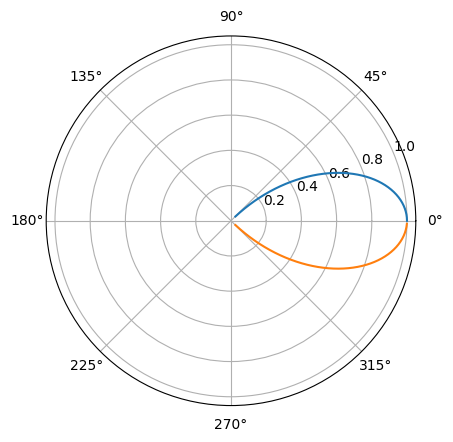

In [21]:
tm = np.arange(0,360,1)

input_wave = np.cos(mult*np.radians(tm))
plt.polar(np.radians(tm)[:90//mult],input_wave[:90//mult])
plt.polar(np.radians(tm)[len(input_wave)-(90//mult):],input_wave[len(input_wave)-(90//mult):])
plt.show()